In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import rand_score
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import time
import scipy.io

In [2]:
def statistical_leverage(data):
    n, d = data.shape
    u, s, v = np.linalg.svd(data)
    l = []

    for i in range(n):
        l.append(np.linalg.norm(u[i]))
    
    return l / np.sum(l)

In [3]:
traindata = pd.DataFrame(pd.read_csv("bio_train.dat", sep="\t", header=None))
traindata.dropna()
traindata.drop_duplicates()
traindata = traindata[:10000]

In [4]:
traindata.shape

(10000, 77)

In [5]:
kmeans = KMeans(n_clusters=50, init="k-means++", random_state=42).fit(traindata)
centers = kmeans.cluster_centers_

C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [6]:
def kmeans_cost(data, centers, labels):
    cost = 0.0
    for i in range(len(data)):
        distance = np.linalg.norm(data[i] - centers[labels[i]]) ** 2
        cost += distance
    return cost

In [7]:
cost = kmeans_cost(traindata.values, centers, kmeans.labels_)
optimal_labels = kmeans.labels_
print(f'Cost of KMeans: {cost}')

Cost of KMeans: 20240766450.871975


In [8]:
coreset_size = [500, 1000, 2000, 5000, 7000, 10000]
results = []

probabilities = statistical_leverage(traindata.values)
for ssize in coreset_size:
    tic = time.time()
    avg_cost = 0.0
    rand_index = 0.0
    for _ in range(5):
        indices = np.random.choice(traindata.shape[0], size=ssize, replace=False, p=probabilities)
        X_samples = traindata.values[indices]
        kmeans = KMeans(n_clusters= 50, init="k-means++").fit(X_samples)
        labels = kmeans.predict(traindata.values)
        centers = kmeans.cluster_centers_
        avg_cost += kmeans_cost(traindata.values, centers, labels)
        rand_index += rand_score(optimal_labels, labels)
    rand_index /= 5
    avg_cost /= 5
    toc = time.time()
    reduction = ((traindata.shape[0] - X_samples.shape[0])/traindata.shape[0])*100
    error = (abs(avg_cost - cost)/cost)*100
    results.append({'Sampling Type': 'Statistical Leverage Sampling',
                        'Coreset Size': X_samples.shape[0],
                        'Average Cost': avg_cost,
                        'Reduction in Data Size': reduction,
                        'Error': error,
                        'Avg Rand Index': rand_index,
                        'Data': 'KDD',
                        'Optimal Cost': cost,
                        'Avg Time': (toc - tic)/5})

C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The defa

In [9]:
results_df = pd.DataFrame(results)
results_df

,Sampling Type,Coreset Size,Average Cost,Reduction in Data Size,Error,Avg Rand Index,Data,Optimal Cost,Avg Time
0,Statistical Leverage Sampling,500,5.315079e+10,95.0,162.592764,0.981162,KDD,2.024077e+10,0.545842
1,Statistical Leverage Sampling,1000,4.281110e+10,90.0,111.509275,0.985138,KDD,2.024077e+10,1.419281
2,Statistical Leverage Sampling,2000,3.236914e+10,80.0,59.920526,0.985731,KDD,2.024077e+10,1.887339
3,Statistical Leverage Sampling,5000,2.545636e+10,50.0,25.767764,0.988519,KDD,2.024077e+10,2.283374
4,Statistical Leverage Sampling,7000,2.453497e+10,30.0,21.215624,0.987536,KDD,2.024077e+10,2.361441
5,Statistical Leverage Sampling,10000,2.034479e+10,0.0,0.513953,0.987528,KDD,2.024077e+10,2.073051


In [10]:
csv_file = 'results.csv'
with open(csv_file, 'a') as f:
    results_df.to_csv(f, header=f.tell()==0, index=False)

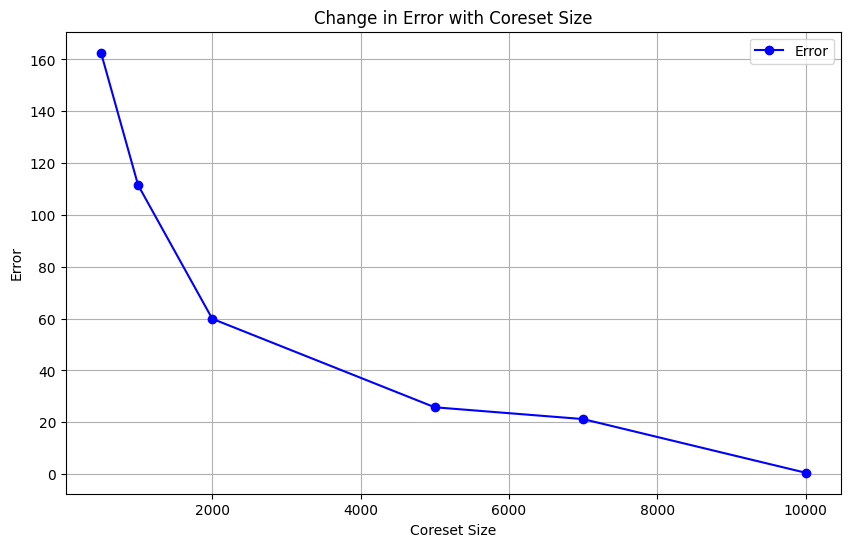

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Error'], marker='o', linestyle='-', color="blue", label="Error")

plt.title('Change in Error with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()

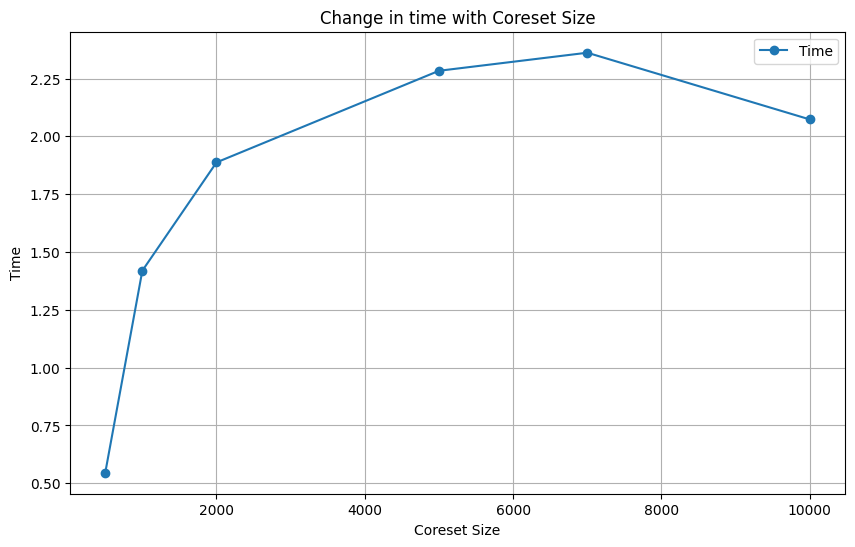

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Avg Time'], marker='o', linestyle='-', label='Time')
plt.legend()
plt.title('Change in time with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Time')
plt.grid(True)
plt.show()

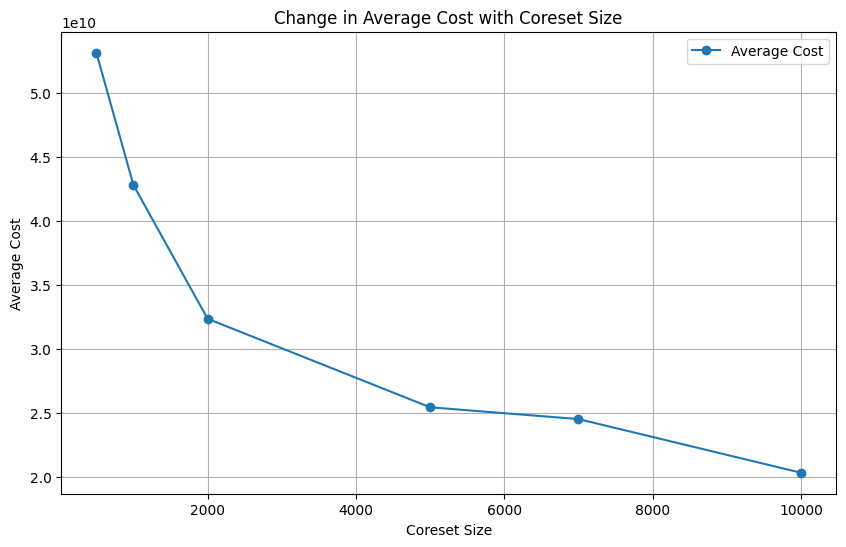

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Average Cost'], marker='o', linestyle='-', label='Average Cost')
plt.legend()
plt.title('Change in Average Cost with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Average Cost')
plt.grid(True)
plt.show()

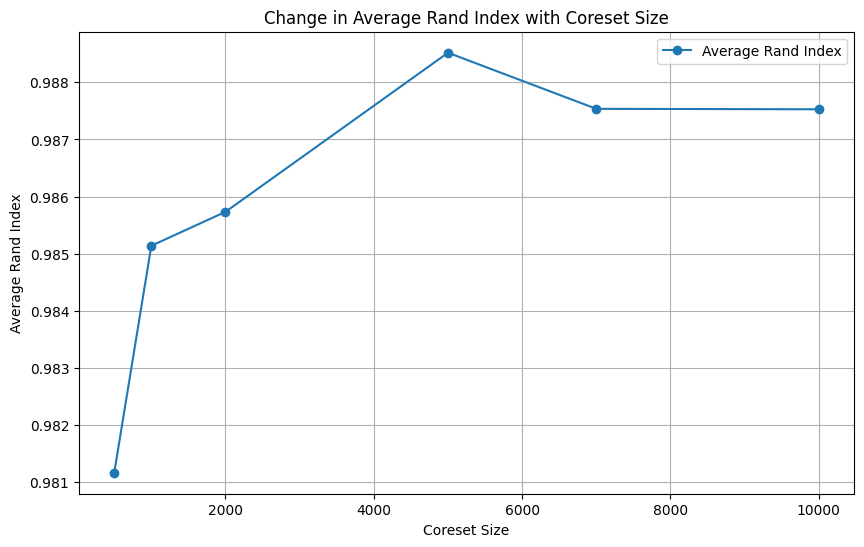

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Avg Rand Index'], marker='o', linestyle='-', label='Average Rand Index')
plt.legend()
plt.title('Change in Average Rand Index with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Average Rand Index')
plt.grid(True)
plt.show()

In [15]:
mat_data = scipy.io.loadmat('olivettifaces.mat')
mat_data['faces'].shape

(4096, 400)

In [16]:
traindata = mat_data['faces'].T
traindata.shape

(400, 4096)

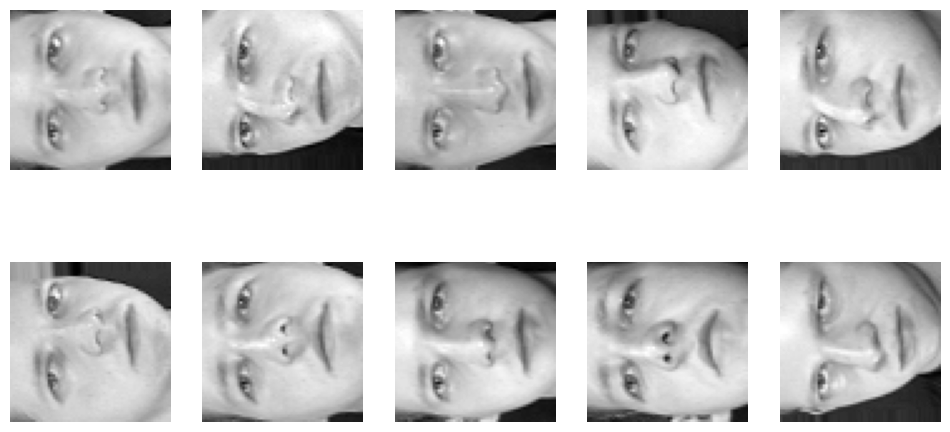

In [17]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(traindata[i].T.reshape(64, 64), cmap='gray')
    ax.axis('off')

plt.show()

In [18]:
traindata = pd.DataFrame(traindata)
traindata.dropna()
traindata.drop_duplicates()
traindata.shape

(400, 4096)

In [19]:
kmeans = KMeans(n_clusters=50, init="k-means++", random_state=42).fit(traindata)
optimal_labels = kmeans.labels_
centers = kmeans.cluster_centers_

C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [20]:
cost = kmeans_cost(traindata.values, centers, optimal_labels)
print(f'Cost of KMeans: {cost}')

Cost of KMeans: 624700740.2474288


In [21]:
coreset_size = [5, 10, 20, 50, 70, 100]
results = []

probabilities = statistical_leverage(traindata.values)
for ssize in coreset_size:
    tic = time.time()
    avg_cost = 0.0
    rand_index = 0.0
    for _ in range(5):
        indices = np.random.choice(traindata.shape[0], size=ssize, replace=False, p=probabilities)
        X_samples = traindata.values[indices]
        kmeans = KMeans(n_clusters= 5, init="k-means++").fit(X_samples)
        labels = kmeans.predict(traindata.values)
        centers = kmeans.cluster_centers_
        avg_cost += kmeans_cost(traindata.values, centers, labels)
        rand_index += rand_score(optimal_labels, labels)
    rand_index /= 5
    avg_cost /= 5
    toc = time.time()
    reduction = ((traindata.shape[0] - X_samples.shape[0])/traindata.shape[0])*100
    error = (abs(avg_cost - cost)/cost)*100
    results.append({'Sampling Type': 'Statistical Leverage Sampling',
                        'Coreset Size': X_samples.shape[0],
                        'Average Cost': avg_cost,
                        'Reduction in Data Size': reduction,
                        'Error': error,
                        'Avg Rand Index': rand_index,
                        'Data': 'Face',
                        'Optimal Cost': cost,
                        'Avg Time': (toc - tic)/5})

C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The defa

In [22]:
results_df = pd.DataFrame(results)
results_df

,Sampling Type,Coreset Size,Average Cost,Reduction in Data Size,Error,Avg Rand Index,Data,Optimal Cost,Avg Time
0,Statistical Leverage Sampling,5,2.412468e+09,98.75,286.179738,0.719674,Face,6.247007e+08,0.081136
1,Statistical Leverage Sampling,10,1.910908e+09,97.50,205.891753,0.703657,Face,6.247007e+08,0.064819
2,Statistical Leverage Sampling,20,1.624874e+09,95.00,160.104439,0.758381,Face,6.247007e+08,0.072770
3,Statistical Leverage Sampling,50,1.443713e+09,87.50,131.104701,0.733992,Face,6.247007e+08,0.120424
4,Statistical Leverage Sampling,70,1.386172e+09,82.50,121.893776,0.768892,Face,6.247007e+08,0.141691
5,Statistical Leverage Sampling,100,1.350021e+09,75.00,116.106817,0.773734,Face,6.247007e+08,0.181299


In [23]:
csv_file = 'results.csv'
with open(csv_file, 'a') as f:
    results_df.to_csv(f, header=f.tell()==0, index=False)

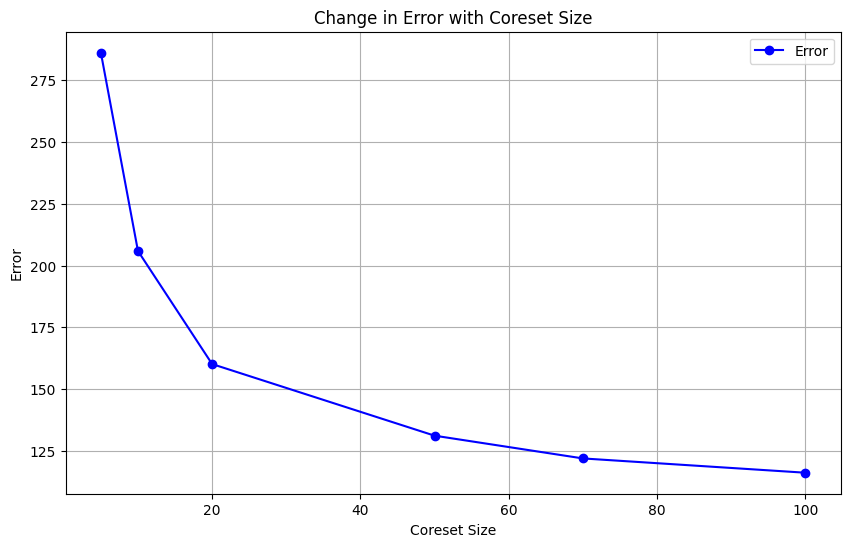

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Error'], marker='o', linestyle='-', color="blue", label="Error")

plt.title('Change in Error with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()

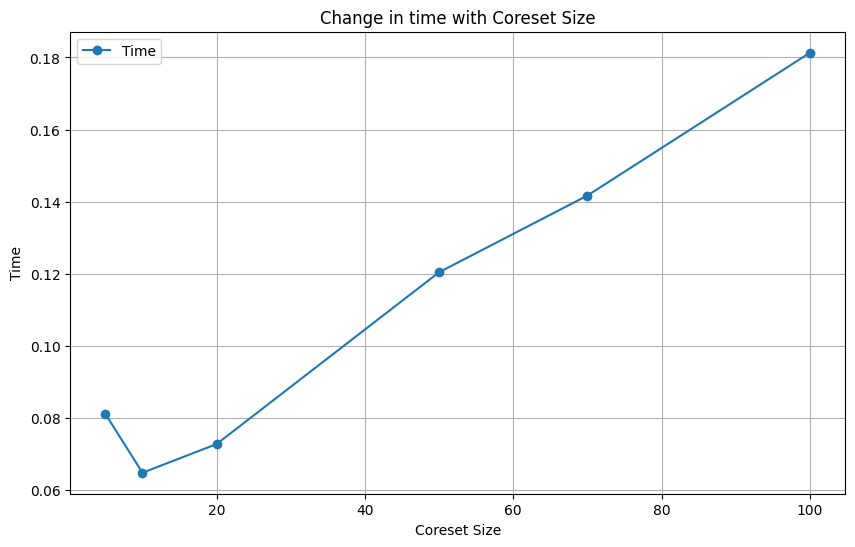

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Avg Time'], marker='o', linestyle='-', label='Time')
plt.legend()
plt.title('Change in time with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Time')
plt.grid(True)
plt.show()

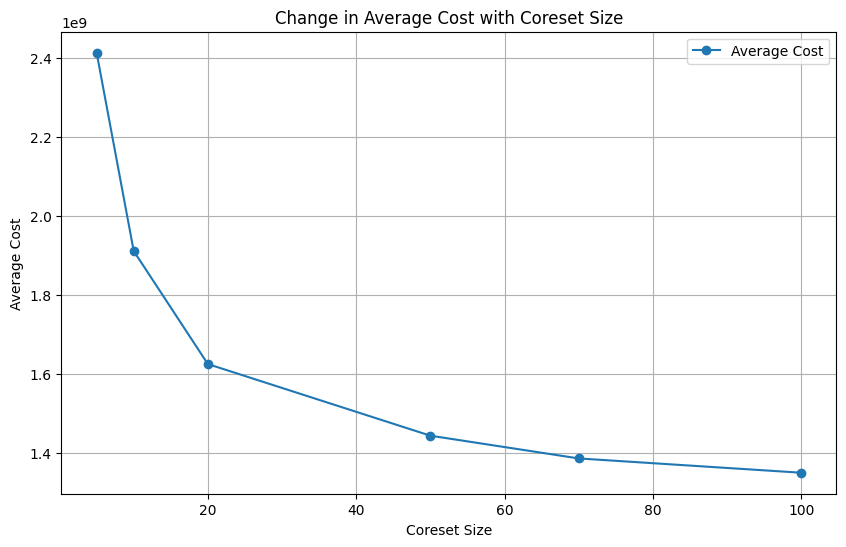

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Average Cost'], marker='o', linestyle='-', label='Average Cost')
plt.legend()
plt.title('Change in Average Cost with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Average Cost')
plt.grid(True)
plt.show()

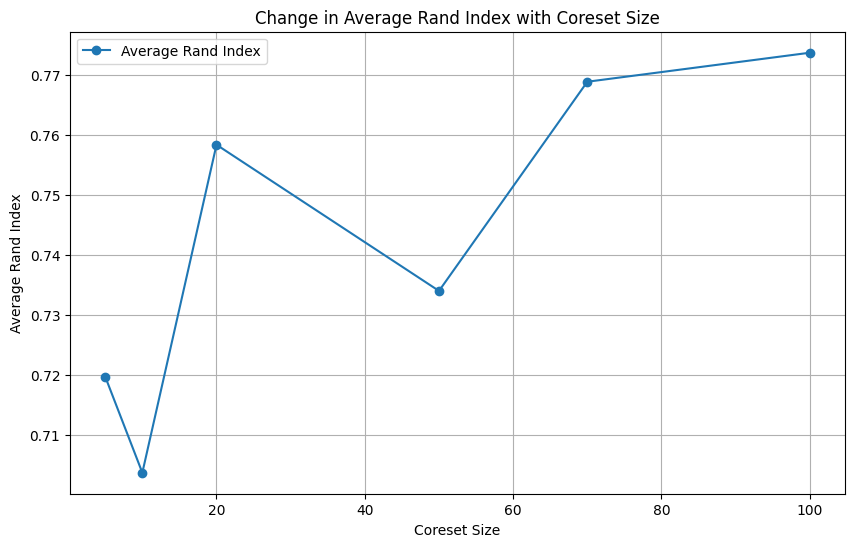

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Avg Rand Index'], marker='o', linestyle='-', label='Average Rand Index')
plt.legend()
plt.title('Change in Average Rand Index with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Average Rand Index')
plt.grid(True)
plt.show()

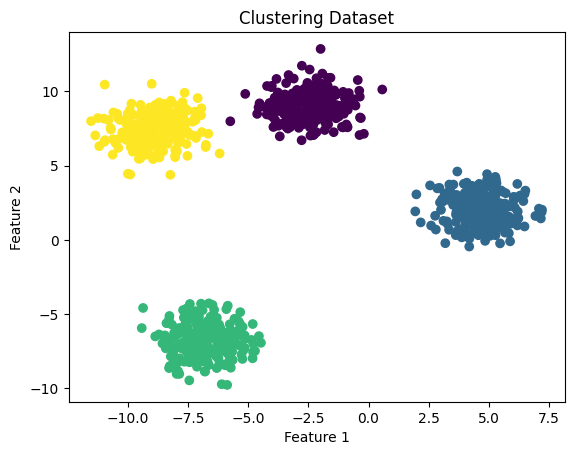

In [28]:
traindata, optimal_labels = make_blobs(n_samples=1000, centers=4, random_state=42)

plt.scatter(traindata[:, 0], traindata[:, 1], c=optimal_labels)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Clustering Dataset')
plt.show()

In [29]:
kmeans = KMeans(n_clusters=4, init="k-means++", random_state=42).fit(traindata)
centers = kmeans.cluster_centers_

C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [30]:
cost = kmeans_cost(traindata, centers, optimal_labels)
print(f'Cost of KMeans: {cost}')

Cost of KMeans: 106042.08028259652


In [31]:
coreset_size = [50, 100, 200, 500, 700, 1000]
results = []

probabilities = statistical_leverage(traindata)
for ssize in coreset_size:
    tic = time.time()
    avg_cost = 0.0
    rand_index = 0.0
    for _ in range(5):
        indices = np.random.choice(traindata.shape[0], size=ssize, replace=False, p=probabilities)
        X_samples = traindata[indices]
        kmeans = KMeans(n_clusters= 5, init="k-means++").fit(X_samples)
        labels = kmeans.predict(traindata)
        centers = kmeans.cluster_centers_
        avg_cost += kmeans_cost(traindata, centers, labels)
        rand_index += rand_score(optimal_labels, labels)
    rand_index /= 5
    avg_cost /= 5
    toc = time.time()
    reduction = ((traindata.shape[0] - X_samples.shape[0])/traindata.shape[0])*100
    error = (abs(avg_cost - cost)/cost)*100
    results.append({'Sampling Type': 'Statistical Leverage Sampling',
                        'Coreset Size': X_samples.shape[0],
                        'Average Cost': avg_cost,
                        'Reduction in Data Size': reduction,
                        'Error': error,
                        'Avg Rand Index': rand_index,
                        'Data': 'Blob',
                        'Optimal Cost': cost,
                        'Avg Time': (toc - tic)/5})

C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The defa

In [32]:
results_df = pd.DataFrame(results)
results_df

,Sampling Type,Coreset Size,Average Cost,Reduction in Data Size,Error,Avg Rand Index,Data,Optimal Cost,Avg Time
0,Statistical Leverage Sampling,50,1973.925276,95.0,98.138545,0.974647,Blob,106042.080283,0.050148
1,Statistical Leverage Sampling,100,1863.253021,90.0,98.242912,0.969376,Blob,106042.080283,0.053053
2,Statistical Leverage Sampling,200,1815.719103,80.0,98.287737,0.969122,Blob,106042.080283,0.044811
3,Statistical Leverage Sampling,500,1783.130952,50.0,98.318469,0.968151,Blob,106042.080283,0.051734
4,Statistical Leverage Sampling,700,1779.464348,30.0,98.321926,0.967891,Blob,106042.080283,0.056750
5,Statistical Leverage Sampling,1000,1769.459267,0.0,98.331361,0.967865,Blob,106042.080283,0.067681


In [33]:
csv_file = 'results.csv'
with open(csv_file, 'a') as f:
    results_df.to_csv(f, header=f.tell()==0, index=False)

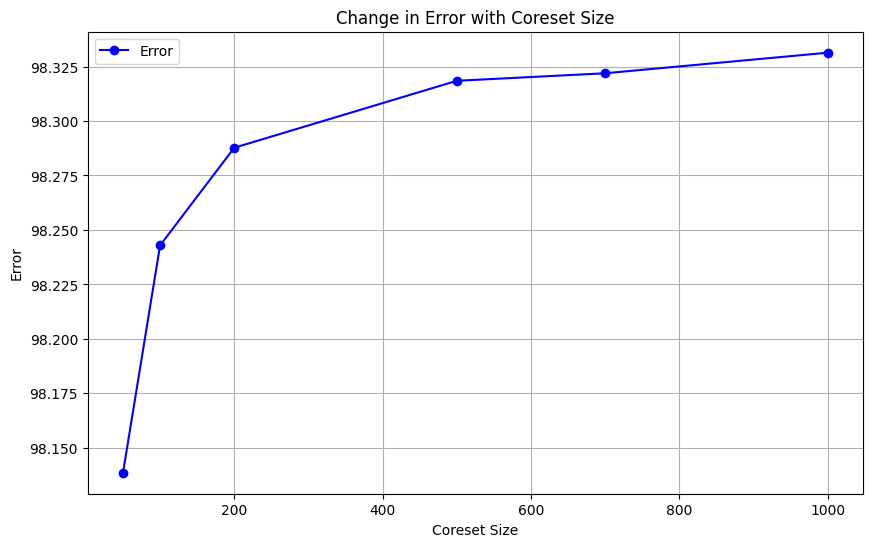

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Error'], marker='o', linestyle='-', color="blue", label="Error")

plt.title('Change in Error with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()

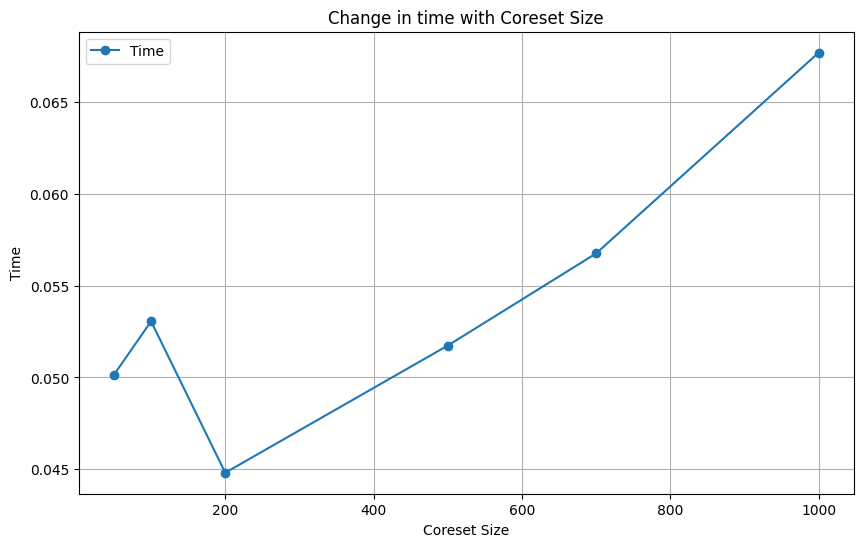

In [35]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Avg Time'], marker='o', linestyle='-', label='Time')
plt.legend()
plt.title('Change in time with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Time')
plt.grid(True)
plt.show()

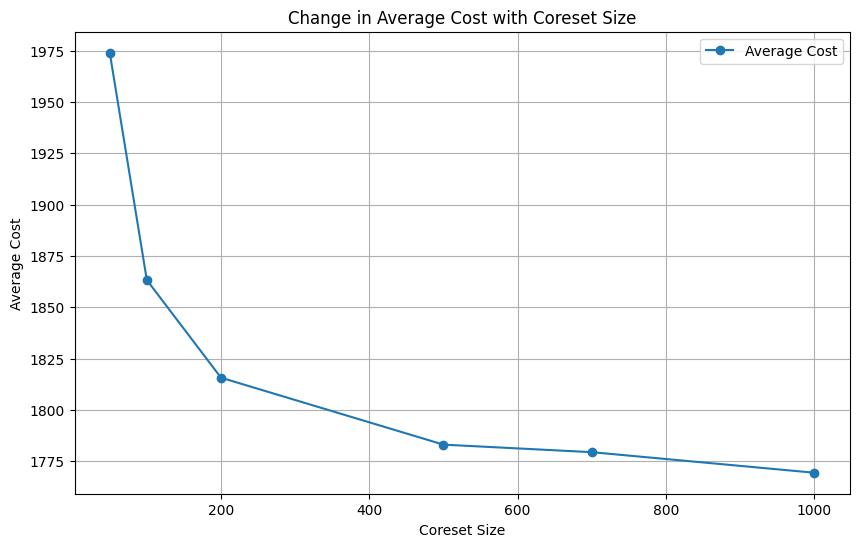

In [36]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Average Cost'], marker='o', linestyle='-', label='Average Cost')
plt.legend()
plt.title('Change in Average Cost with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Average Cost')
plt.grid(True)
plt.show()

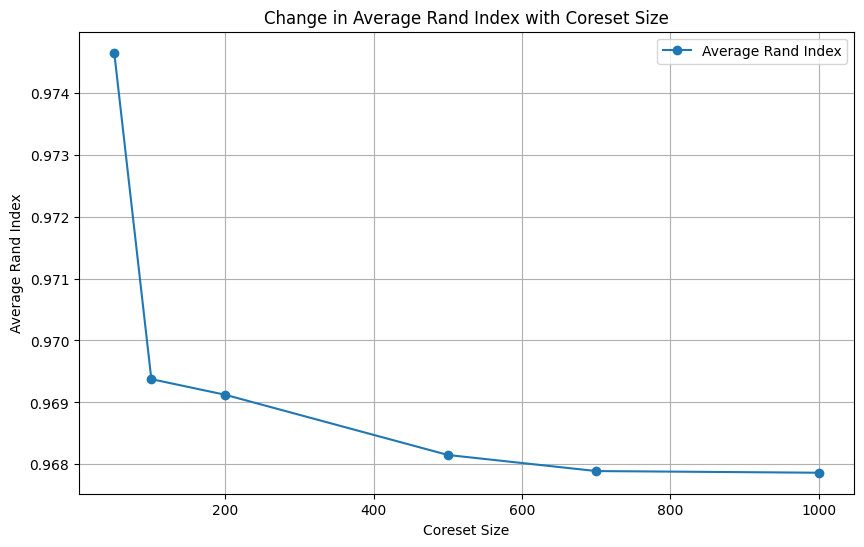

In [37]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Avg Rand Index'], marker='o', linestyle='-', label='Average Rand Index')
plt.legend()
plt.title('Change in Average Rand Index with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Average Rand Index')
plt.grid(True)
plt.show()

In [38]:
from keras.datasets import mnist
import numpy as np

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images / 255.0
test_images = test_images / 255.0

test_images_vector = test_images.reshape(test_images.shape[0], -1)
train_images_vector = train_images.reshape(train_images.shape[0], -1)

print(np.shape(test_images_vector))
print(np.shape(train_images_vector))

(10000, 784)
(60000, 784)


In [39]:
traindata = train_images_vector

In [40]:
kmeans = KMeans(n_clusters=10, init="k-means++", random_state=42).fit(traindata)
optimal_labels = train_labels
centers = kmeans.cluster_centers_

C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [41]:
cost = kmeans_cost(traindata, centers, optimal_labels)
print(f'Cost of KMeans: {cost}')

Cost of KMeans: 3977948.5301497704


In [44]:
coreset_size = [500, 1000, 2000, 5000, 7000, 10000]
results = []
traindata = traindata[:10000]
optimal_labels = optimal_labels[:10000]

probabilities = statistical_leverage(traindata)
for ssize in coreset_size:
    tic = time.time()
    avg_cost = 0.0
    rand_index = 0.0
    for _ in range(5):
        indices = np.random.choice(traindata.shape[0], size=ssize, replace=False, p=probabilities)
        X_samples = traindata[indices]
        kmeans = KMeans(n_clusters= 5, init="k-means++").fit(X_samples)
        labels = kmeans.predict(traindata)
        centers = kmeans.cluster_centers_
        avg_cost += kmeans_cost(traindata, centers, labels)
        rand_index += rand_score(optimal_labels, labels)
    rand_index /= 5
    avg_cost /= 5
    toc = time.time()
    reduction = ((traindata.shape[0] - X_samples.shape[0])/traindata.shape[0])*100
    error = (abs(avg_cost - cost)/cost)*100
    results.append({'Sampling Type': 'Statistical Leverage Sampling',
                        'Coreset Size': X_samples.shape[0],
                        'Average Cost': avg_cost,
                        'Reduction in Data Size': reduction,
                        'Error': error,
                        'Avg Rand Index': rand_index,
                        'Data': 'MNIST',
                        'Optimal Cost': cost,
                        'Avg Time': (toc - tic)/5})

C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The defa

In [45]:
results_df = pd.DataFrame(results)
results_df

,Sampling Type,Coreset Size,Average Cost,Reduction in Data Size,Error,Avg Rand Index,Data,Optimal Cost,Avg Time
0,Statistical Leverage Sampling,500,436791.413363,95.0,89.019682,0.811466,MNIST,3.977949e+06,0.277431
1,Statistical Leverage Sampling,1000,434129.289830,90.0,89.086604,0.811448,MNIST,3.977949e+06,0.398797
2,Statistical Leverage Sampling,2000,432629.739512,80.0,89.124300,0.812969,MNIST,3.977949e+06,0.696656
3,Statistical Leverage Sampling,5000,431842.102626,50.0,89.144100,0.813437,MNIST,3.977949e+06,2.107356
4,Statistical Leverage Sampling,7000,431697.215510,30.0,89.147743,0.812349,MNIST,3.977949e+06,2.244243
5,Statistical Leverage Sampling,10000,431574.432251,0.0,89.150829,0.812325,MNIST,3.977949e+06,3.238709


In [46]:
csv_file = 'results.csv'
with open(csv_file, 'a') as f:
    results_df.to_csv(f, header=f.tell()==0, index=False)

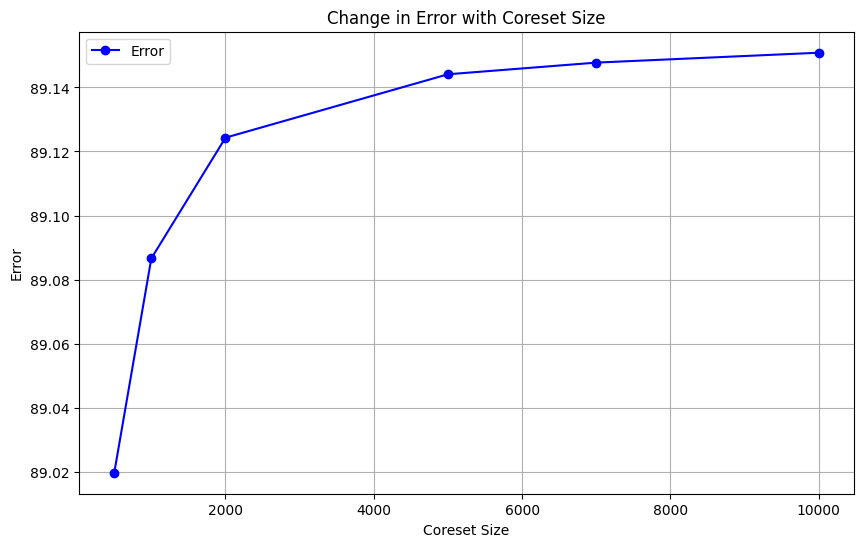

In [47]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Error'], marker='o', linestyle='-', color="blue", label="Error")

plt.title('Change in Error with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()

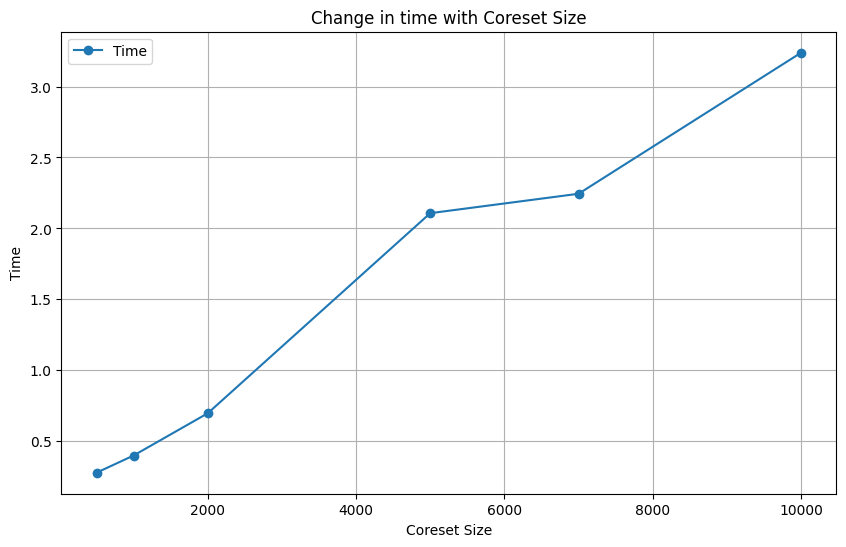

In [48]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Avg Time'], marker='o', linestyle='-', label='Time')
plt.legend()
plt.title('Change in time with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Time')
plt.grid(True)
plt.show()

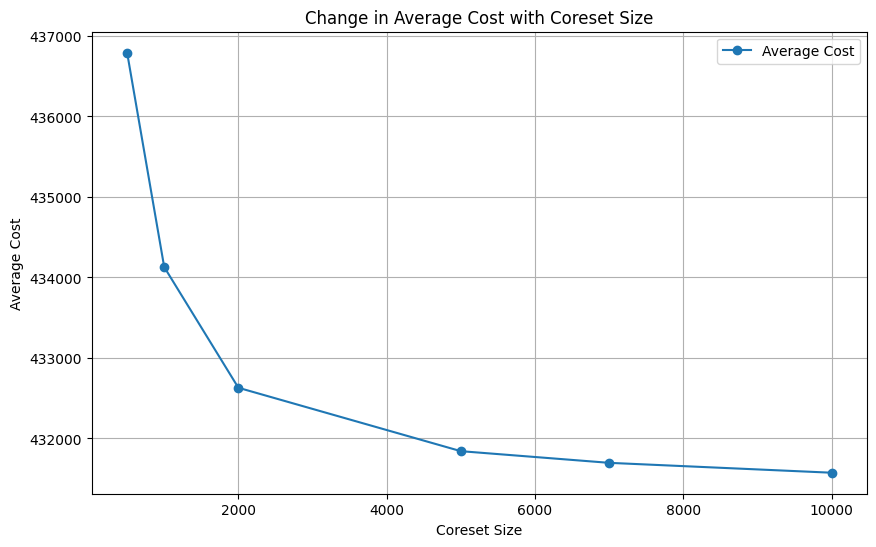

In [49]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Average Cost'], marker='o', linestyle='-', label='Average Cost')
plt.legend()
plt.title('Change in Average Cost with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Average Cost')
plt.grid(True)
plt.show()

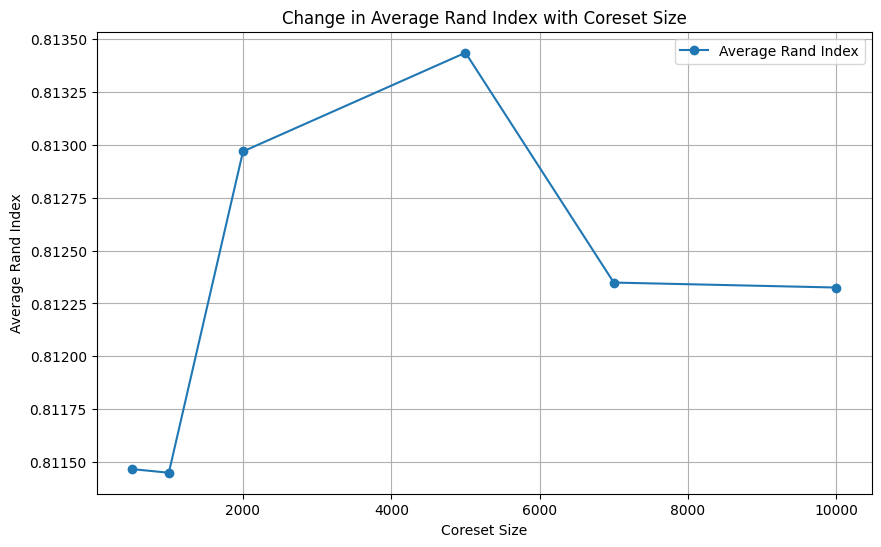

In [50]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Avg Rand Index'], marker='o', linestyle='-', label='Average Rand Index')
plt.legend()
plt.title('Change in Average Rand Index with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Average Rand Index')
plt.grid(True)
plt.show()